                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.245
Model:                            OLS   Adj. R-squared:                  0.208
Method:                 Least Squares   F-statistic:                     6.703
Date:                Fri, 08 May 2026   Prob (F-statistic):           2.67e-08
Time:                        13:27:47   Log-Likelihood:                -1126.2
No. Observations:                 196   AIC:                             2272.
Df Residuals:                     186   BIC:                             2305.
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 

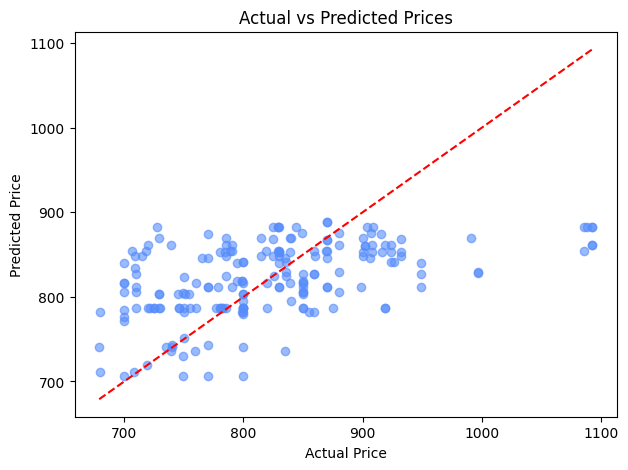

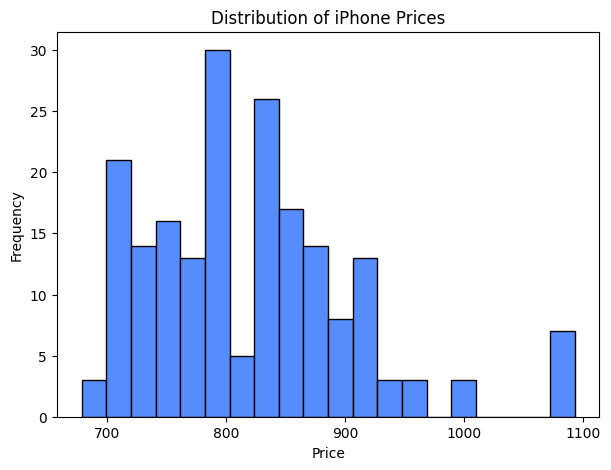

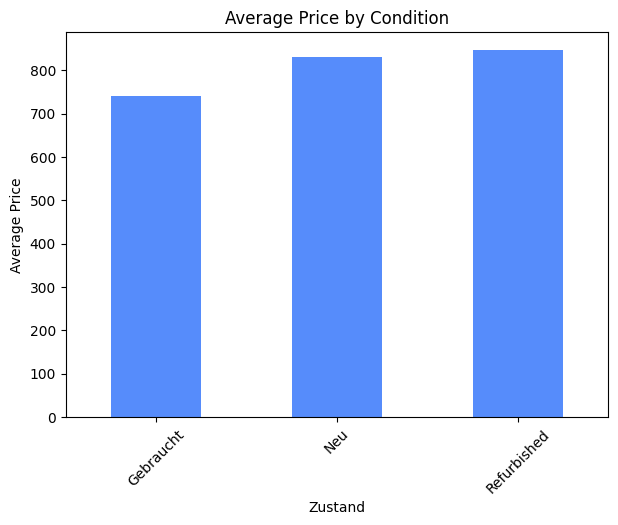

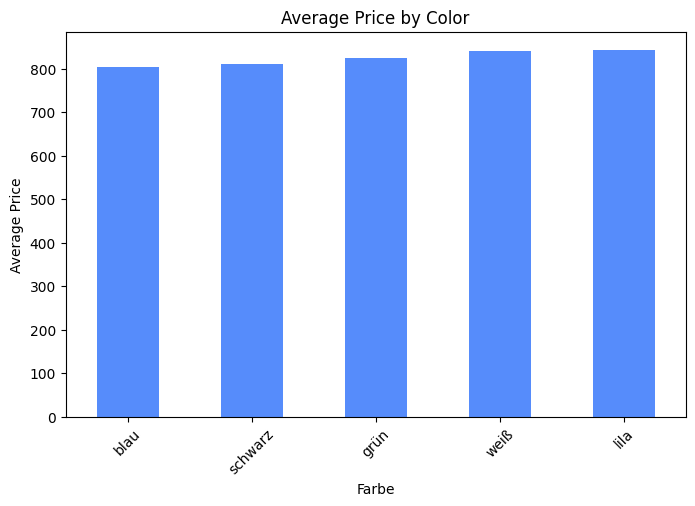

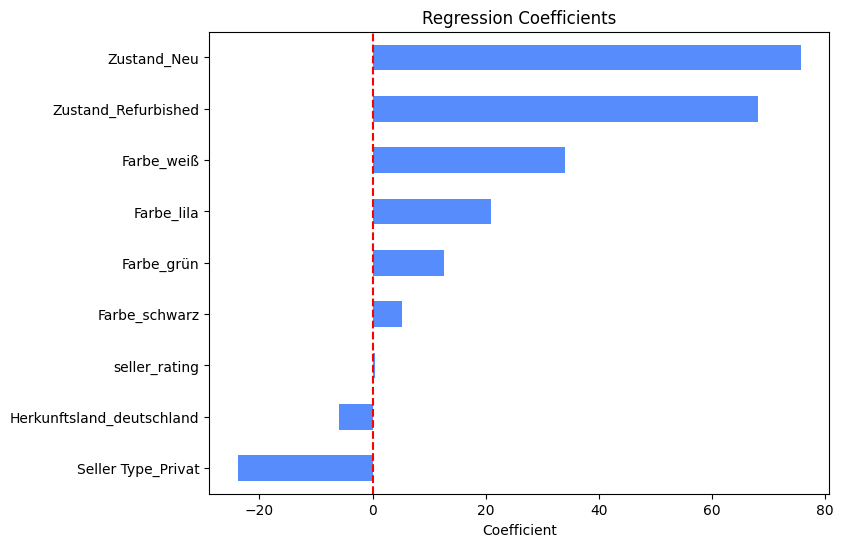

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import statsmodels.api as sm
from color_mapping import clean_color_column
from country_mapping import clean_country_column

file_path = os.path.expanduser("~/Desktop/regge.xlsx")
df = pd.read_excel(file_path)

model_full = df[
    ["Preis", "Zustand", "Farbe", "Seller Rating", "Seller Type", "Herkunftsland"]
].copy()


def clean_price(x):
    if pd.isna(x):
        return np.nan
    x = (
        str(x)
        .replace("EUR", "")
        .replace("€", "")
        .replace(".", "")
        .replace(",", ".")
        .strip()
    )
    try:
        return float(x)
    except:
        return np.nan


def clean_rating(x):
    if pd.isna(x) or x == "N/A":
        return np.nan
    x = str(x).replace("%", "").replace(",", ".").strip()
    try:
        return float(x)
    except:
        return np.nan


model_full["price"] = model_full["Preis"].apply(clean_price)
model_full["seller_rating"] = model_full["Seller Rating"].apply(clean_rating)
model_full["Farbe"] = model_full["Farbe"].astype(str).str.lower().str.strip()
model_full["Farbe"] = clean_color_column(model_full["Farbe"])
model_full["Herkunftsland"] = clean_country_column(model_full["Herkunftsland"])
model_full = model_full.drop(columns=["Preis", "Seller Rating"])
model_full = model_full.dropna()

model_full_encoded = pd.get_dummies(
    model_full,
    columns=["Zustand", "Farbe", "Seller Type", "Herkunftsland"],
    drop_first=True,
)

X = model_full_encoded.drop("price", axis=1)
y = model_full_encoded["price"]

X = X.astype(float)
y = y.astype(float)

X = sm.add_constant(X)

model_B = sm.OLS(y, X).fit()

print(model_B.summary())

print("Observations:", len(y))
print("R²:", model_B.rsquared)
print("Adjusted R²:", model_B.rsquared_adj)

model_full_encoded["predicted_price"] = model_B.predict(X)
model_full_encoded["residual"] = y - model_full_encoded["predicted_price"]


# Visualisierungen
plt.figure(figsize=(7, 5))
plt.scatter(y, model_full_encoded["predicted_price"], alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], "r--")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices")
plt.show()

plt.figure(figsize=(7, 5))
plt.hist(y, bins=20, edgecolor="black")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.title("Distribution of iPhone Prices")
plt.show()
model_full.groupby("Zustand")["price"].mean().sort_values().plot(
    kind="bar", figsize=(7, 5)
)
plt.ylabel("Average Price")
plt.title("Average Price by Condition")
plt.xticks(rotation=45)
plt.show()

model_full.groupby("Farbe")["price"].mean().sort_values().plot(
    kind="bar", figsize=(8, 5)
)
plt.ylabel("Average Price")
plt.title("Average Price by Color")
plt.xticks(rotation=45)
plt.show()

coef = model_B.params.drop("const").sort_values()

plt.figure(figsize=(8, 6))
coef.plot(kind="barh")
plt.axvline(0, color="red", linestyle="--")
plt.xlabel("Coefficient")
plt.title("Regression Coefficients")
plt.show()

In [6]:
import pandas as pd
import numpy as np
import os
import statsmodels.api as sm
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 1. Datei laden
file_path = os.path.expanduser("~/Desktop/regge.xlsx")
df = pd.read_excel(file_path)

# 2. Preis bereinigen
def clean_numeric(val):
    if pd.isna(val) or val == '': return np.nan
    s = str(val).replace('€', '').replace('EUR', '').replace('.', '').replace(',', '.').strip()
    try:
        return float(s)
    except:
        return np.nan

df['Preis'] = df['Preis'].apply(clean_numeric)

# 3. Kategorische Features encoden
categorical_cols = ['Farbe']
df_final = pd.get_dummies(df, columns=categorical_cols, drop_first=True, dtype=float)

# 4. Zielvariable definieren
y = df_final['Preis']

# 5. X definieren
X = df_final.select_dtypes(include=[np.number]).drop(columns=['Preis'])

# 6. Fehlende Werte entfernen
mask = y.notna() & X.notna().all(axis=1)
X = X[mask]
y = y[mask]

# --- NEU: FILTER FÜR PERFEKTE KORRELATION (Behebt den Error) ---
# Entfernt Variablen, die zu 100% identisch mit anderen sind
corr_matrix = X.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.99)]
X = X.drop(columns=to_drop)

if len(X) == 0:
    print("Fehler: Keine Daten übrig.")
else:
    print(f"\nEntfernte identische Spalten: {to_drop}")

    print("\n" + "="*30)
    print("1. KORRELATION MIT PREIS")
    print("="*30)
    full_df = pd.concat([X, y], axis=1)
    print(full_df.corr()['Preis'].sort_values(ascending=False))

    print("\n" + "="*30)
    print("2. MULTIKOLINEARITÄT (VIF)")
    print("="*30)
    X_vif = sm.add_constant(X)
    vif_data = pd.DataFrame()
    vif_data["Feature"] = X_vif.columns
    # VIF Berechnung mit Error-Handling
    vifs = []
    for i in range(len(X_vif.columns)):
        try:
            vifs.append(variance_inflation_factor(X_vif.values, i))
        except:
            vifs.append(np.inf)
    vif_data["VIF"] = vifs
    print(vif_data[vif_data['Feature'] != 'const'])

    # --- LASSO FEATURE SELECTION ---
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    lasso = LassoCV(cv=5, random_state=42).fit(X_scaled, y)
    selected_features = X.columns[lasso.coef_ != 0].tolist()

    print("\n" + "="*30)
    print("3. LASSO ERGEBNISSE")
    print("="*30)
    print(f"Behaltene Features: {selected_features}")

    # --- 7. Finales OLS Modell ---
    if len(selected_features) > 0:
        X_selected = X[selected_features]
        X_selected = sm.add_constant(X_selected)
        model = sm.OLS(y, X_selected).fit()
        print("\n" + "="*30)
        print("4. FINALE REGRESSION")
        print("="*30)
        print(model.summary())

#We have perfect multicolliniarinity between some Prädiktors


Entfernte identische Spalten: []

1. KORRELATION MIT PREIS
Preis                          1.000000
zahl der verkauften artikel    0.204735
Farbe_Schwarz                  0.104319
Farbe_Weiß                     0.100216
Farbe_Lila                     0.096180
Farbe_Salbei                   0.092738
Farbe_lavendel                 0.049395
Farbe_Sage                    -0.048880
Farbe_Blau                    -0.065200
Farbe_Lila - Lavandel         -0.168836
Farbe_Grün                    -0.202665
Farbe_Violett                 -0.206402
verkauft                      -0.560194
Batteriezustand                     NaN
Farbe_Lavendel                      NaN
Farbe_Lavender                      NaN
Farbe_White                         NaN
Farbe_nebelblau                     NaN
Farbe_salbei                        NaN
Farbe_schwarz                       NaN
Farbe_weiß                          NaN
Name: Preis, dtype: float64

2. MULTIKOLINEARITÄT (VIF)
                        Feature       VIF
0 

/Users/excalibrator/PycharmProjects/SMLab_iPhone17/.venv/lib/python3.14/site-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
/Users/excalibrator/PycharmProjects/SMLab_iPhone17/.venv/lib/python3.14/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)
/Users/excalibrator/PycharmProjects/SMLab_iPhone17/.venv/lib/python3.14/site-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.centered_tss


                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.252
Model:                            OLS   Adj. R-squared:                  0.212
Method:                 Least Squares   F-statistic:                     6.245
Date:                Fri, 08 May 2026   Prob (F-statistic):           3.25e-08
Time:                        14:21:27   Log-Likelihood:                -1125.3
No. Observations:                 196   AIC:                             2273.
Df Residuals:                     185   BIC:                             2309.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 

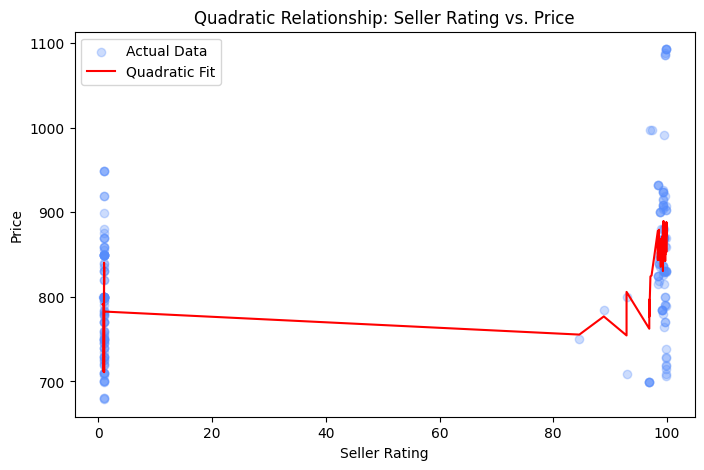

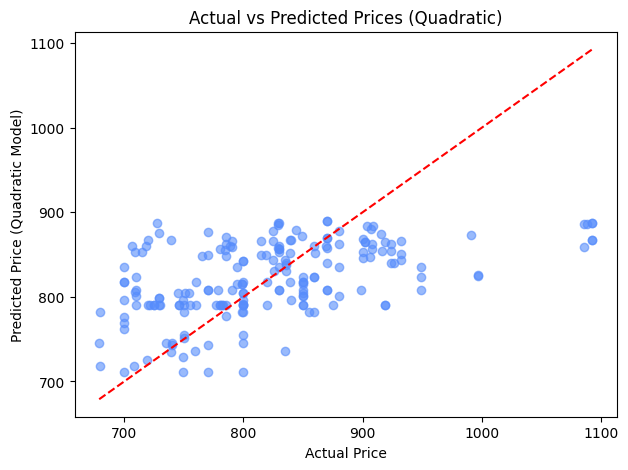

TypeError: '<' not supported between instances of 'int' and 'str'

In [4]:
# ... [Keep your cleaning and encoding code the same] ...

# 1. Create the Quadratic Term (Squaring Seller Rating)
model_full_encoded['seller_rating_squared'] = model_full_encoded['seller_rating'] ** 2

# 2. Update X to include the new term
# Ensure 'seller_rating_squared' is in your features
X = model_full_encoded.drop(["price", "predicted_price", "residual"], axis=1, errors='ignore')
y = model_full_encoded["price"]

X = X.astype(float)
y = y.astype(float)
X = sm.add_constant(X)

# 3. Fit the Quadratic Model
model_B_quad = sm.OLS(y, X).fit()

print(model_B_quad.summary())

# 4. Generate Predictions
model_full_encoded["predicted_price_quad"] = model_B_quad.predict(X)

# --- VISUALIZING THE QUADRATIC EFFECT ---
plt.figure(figsize=(8, 5))
# Sort for a smooth line plot
sorted_df = model_full_encoded.sort_values('seller_rating')
plt.scatter(model_full_encoded['seller_rating'], y, alpha=0.3, label='Actual Data')
plt.plot(sorted_df['seller_rating'], sorted_df['predicted_price_quad'], color='red', label='Quadratic Fit')
plt.xlabel("Seller Rating")
plt.ylabel("Price")
plt.title("Quadratic Relationship: Seller Rating vs. Price")
plt.legend()
plt.show()

# Standard Prediction Plot
plt.figure(figsize=(7, 5))
plt.scatter(y, model_full_encoded["predicted_price_quad"], alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], "r--")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price (Quadratic Model)")
plt.title("Actual vs Predicted Prices (Quadratic)")
plt.show()

# Urutkan dataframe berdasarkan X agar garis plot mulus
df_sorted = df.sort_values(by='Seller Rating')

# Plot data asli
plt.scatter(df['Seller Rating'], df['Price'], alpha=0.3)

# Plot garis prediksi dari dataframe yang sudah diurutkan
plt.plot(df_sorted['Seller Rating'], df_sorted['quad_preds'], color='red')